# Feature Engineering — Credit Card Fraud Detection

**Goal:** Transform raw data into model-ready features optimized for fraud detection.

### Sections
1. Setup & Load Data
2. Clean Data
3. Feature Engineering
4. Scaling Strategy
5. Train / Test Split
6. Handle Class Imbalance — Three Strategies Compared
7. Build sklearn Pipeline
8. Save Processed Data

---
## 1. Setup & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os, sys, joblib

warnings.filterwarnings('ignore')
sys.path.append(os.path.abspath('..'))

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, RobustScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.combine import SMOTETomek

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110

FRAUD_COLOR = '#ef4444'
LEGIT_COLOR = '#3b82f6'
RANDOM_STATE = 42
TARGET = 'Class'

print('Libraries loaded')

Libraries loaded


In [2]:
df = pd.read_csv('../data/raw/creditcard.csv')
print(f'Shape: {df.shape}')
print(f'Fraud rate: {df[TARGET].mean():.4%}')
df.head(3)

Shape: (284807, 31)
Fraud rate: 0.1727%


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0


---
## 2. Clean Data

In [3]:
# Check for issues
print(f'Missing values: {df.isnull().sum().sum()}')
print(f'Duplicate rows: {df.duplicated().sum():,}')

# Remove duplicates
before = len(df)
df.drop_duplicates(inplace=True)
print(f'Rows removed (duplicates): {before - len(df):,}')
print(f'Final shape: {df.shape}')
print(f'Fraud rate after dedup: {df[TARGET].mean():.4%}')

Missing values: 0
Duplicate rows: 1,081
Rows removed (duplicates): 1,081
Final shape: (283726, 31)
Fraud rate after dedup: 0.1667%


---
## 3. Feature Engineering

Key insight from EDA: Time and Amount are NOT pre-scaled unlike V1-V28.
We extract meaningful features from both.

In [4]:
def engineer_features(df):
    df = df.copy()

    # Time features
    # EDA showed fraud peaks at certain hours — extract hour of day
    df['hour'] = (df['Time'] // 3600) % 24
    df['day']  = (df['Time'] // 86400).astype(int)

    # Amount features
    # Amount is heavily right-skewed — log-transform stabilises it
    df['log_amount'] = np.log1p(df['Amount'])

    # Amount bins — captures risk by transaction size
    df['amount_bin'] = pd.cut(
        df['Amount'],
        bins=[0, 10, 50, 200, 1000, float('inf')],
        labels=['micro', 'small', 'medium', 'large', 'xlarge'],
        include_lowest=True
    )

    # High amount at unusual hour — interaction feature
    # EDA showed fraud peaks at low-traffic hours (0-6am)
    df['high_amount_night'] = (
        (df['Amount'] > 200) & (df['hour'] < 6)
    ).astype(int)

    # Drop original Time and Amount
    # They are replaced by engineered versions
    df.drop(columns=['Time', 'Amount'], inplace=True)

    return df


df = engineer_features(df)

new_features = ['hour', 'day', 'log_amount', 'amount_bin', 'high_amount_night']
print('New features created:')
df[new_features].describe(include='all')

New features created:


,hour,day,log_amount,amount_bin,high_amount_night
count,283726.000000,283726.000000,283726.000000,283726,283726.000000
unique,NaN,NaN,NaN,5,NaN
top,NaN,NaN,NaN,micro,NaN
freq,NaN,NaN,NaN,99821,NaN
mean,14.045646,0.491636,3.153760,NaN,0.005410
std,5.834817,0.499931,1.657080,NaN,0.073355
min,0.000000,0.000000,0.000000,NaN,0.000000
25%,10.000000,0.000000,1.887070,NaN,0.000000
50%,15.000000,0.000000,3.135494,NaN,0.000000
75%,19.000000,1.000000,4.363226,NaN,0.000000


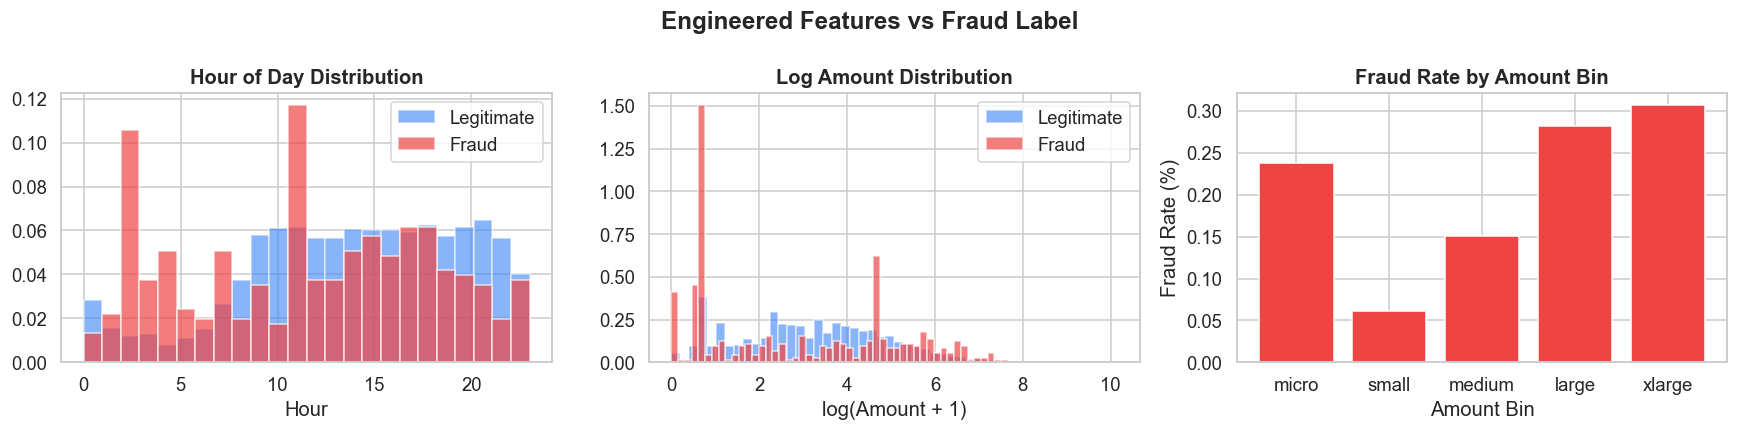

In [5]:
# Validate new features against fraud label
fraud = df[df[TARGET] == 1]
legit = df[df[TARGET] == 0]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Hour distribution
axes[0].hist(legit['hour'], bins=24, alpha=0.6, color=LEGIT_COLOR,
             density=True, label='Legitimate')
axes[0].hist(fraud['hour'], bins=24, alpha=0.7, color=FRAUD_COLOR,
             density=True, label='Fraud')
axes[0].set_title('Hour of Day Distribution', fontweight='bold')
axes[0].set_xlabel('Hour')
axes[0].legend()

# Log amount
axes[1].hist(legit['log_amount'], bins=50, alpha=0.6, color=LEGIT_COLOR,
             density=True, label='Legitimate')
axes[1].hist(fraud['log_amount'], bins=50, alpha=0.7, color=FRAUD_COLOR,
             density=True, label='Fraud')
axes[1].set_title('Log Amount Distribution', fontweight='bold')
axes[1].set_xlabel('log(Amount + 1)')
axes[1].legend()

# Amount bin vs fraud rate
bin_fraud_rate = df.groupby('amount_bin', observed=True)[TARGET].mean() * 100
axes[2].bar(bin_fraud_rate.index.astype(str), bin_fraud_rate.values,
            color=FRAUD_COLOR, edgecolor='white')
axes[2].set_title('Fraud Rate by Amount Bin', fontweight='bold')
axes[2].set_xlabel('Amount Bin')
axes[2].set_ylabel('Fraud Rate (%)')

plt.suptitle('Engineered Features vs Fraud Label', fontweight='bold')
plt.tight_layout()
plt.show()

---
## 4. Scaling Strategy

Why RobustScaler instead of StandardScaler?
- StandardScaler uses mean and std — both are heavily influenced by outliers
- RobustScaler uses median and IQR — much more resistant to extreme values
- Fraud transactions often have extreme values — RobustScaler is the right choice

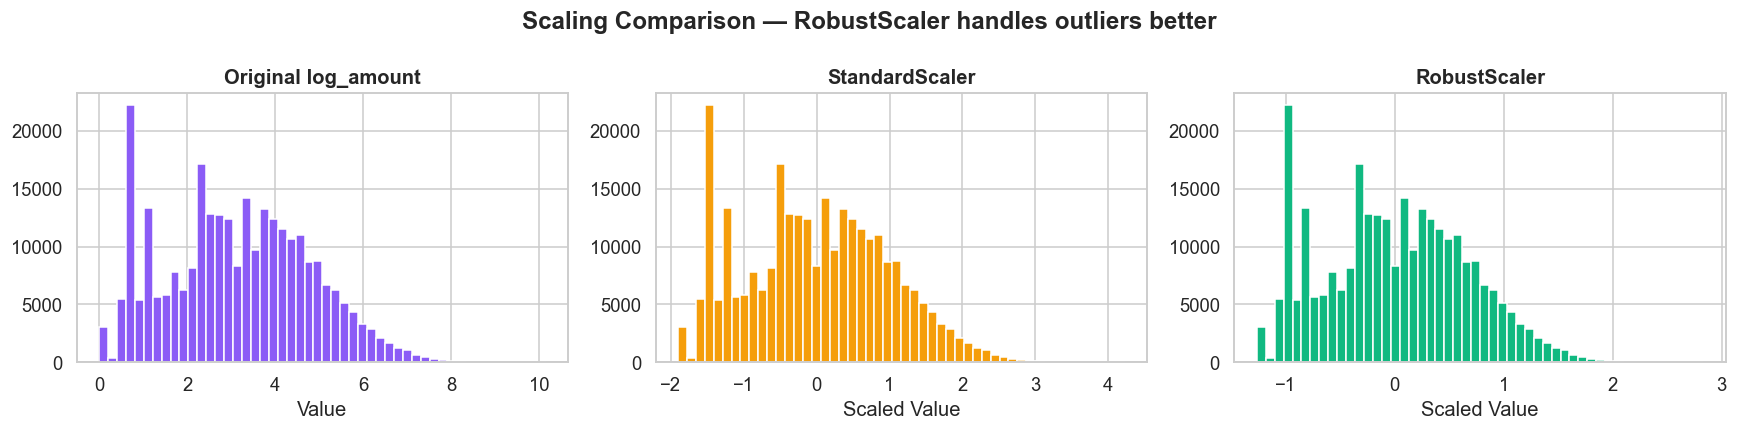

StandardScaler range: [-1.9, 4.2]
RobustScaler range:   [-1.3, 2.8]


In [6]:
# Demonstrate why RobustScaler is better here
from sklearn.preprocessing import StandardScaler, RobustScaler

sample_amounts = df['log_amount'].values.reshape(-1, 1)

std_scaled    = StandardScaler().fit_transform(sample_amounts).flatten()
robust_scaled = RobustScaler().fit_transform(sample_amounts).flatten()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(sample_amounts.flatten(), bins=50, color='#8b5cf6', edgecolor='white')
axes[0].set_title('Original log_amount', fontweight='bold')
axes[0].set_xlabel('Value')

axes[1].hist(std_scaled, bins=50, color='#f59e0b', edgecolor='white')
axes[1].set_title('StandardScaler', fontweight='bold')
axes[1].set_xlabel('Scaled Value')

axes[2].hist(robust_scaled, bins=50, color='#10b981', edgecolor='white')
axes[2].set_title('RobustScaler', fontweight='bold')
axes[2].set_xlabel('Scaled Value')

plt.suptitle('Scaling Comparison — RobustScaler handles outliers better',
             fontweight='bold')
plt.tight_layout()
plt.show()

print(f'StandardScaler range: [{std_scaled.min():.1f}, {std_scaled.max():.1f}]')
print(f'RobustScaler range:   [{robust_scaled.min():.1f}, {robust_scaled.max():.1f}]')

---
## 5. Train / Test Split

In [7]:
X = df.drop(columns=[TARGET])
y = df[TARGET]

# Identify feature types
numeric_cols     = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

print(f'Numeric features ({len(numeric_cols)}):     {numeric_cols[:5]}...')
print(f'Categorical features ({len(categorical_cols)}): {categorical_cols}')
print(f'Total features: {len(X.columns)}')

# Stratified split — critical for imbalanced data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f'\nTrain: {X_train.shape}  |  Test: {X_test.shape}')
print(f'Train fraud rate: {y_train.mean():.4%}')
print(f'Test fraud rate:  {y_test.mean():.4%}')
print('Fraud rate is preserved in both splits (stratified)')

Numeric features (30):     ['V1', 'V2', 'V3', 'V4', 'V5']...
Categorical features (1): ['amount_bin']
Total features: 33

Train: (226980, 33)  |  Test: (56746, 33)
Train fraud rate: 0.1665%
Test fraud rate:  0.1674%
Fraud rate is preserved in both splits (stratified)


---
## 6. Handle Class Imbalance — Three Strategies Compared

Unlike ChurnGuard (26.5% imbalance), fraud has 0.17% — much more extreme.
We compare three resampling strategies:
- **SMOTE** — Synthetic Minority Over-sampling
- **ADASYN** — Adaptive Synthetic Sampling (focuses on harder cases)
- **SMOTETomek** — SMOTE + Tomek Links (oversample minority AND clean boundary)

In [8]:
# First transform the data so we can apply resamplers
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  RobustScaler()),
])
categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot',  OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])
preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_cols),
    ('cat', categorical_transformer, categorical_cols),
])

X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed  = preprocessor.transform(X_test)

print(f'Transformed train shape: {X_train_transformed.shape}')
print(f'Transformed test shape:  {X_test_transformed.shape}')

Transformed train shape: (226980, 35)
Transformed test shape:  (56746, 35)


In [9]:
# Compare three resampling strategies on a 10% sample for speed
# Full dataset is used during actual training in notebook 03
from sklearn.utils import resample as sk_resample

sample_idx = sk_resample(
    range(len(X_train_transformed)),
    n_samples=int(len(X_train_transformed) * 0.1),
    random_state=RANDOM_STATE,
    stratify=y_train
)
X_sample = X_train_transformed[sample_idx]
y_sample  = y_train.iloc[sample_idx].reset_index(drop=True)

strategies = {
    'SMOTE':      SMOTE(random_state=RANDOM_STATE),
    'ADASYN':     ADASYN(random_state=RANDOM_STATE),
    'SMOTETomek': SMOTETomek(random_state=RANDOM_STATE),
}

results = {}
for name, sampler in strategies.items():
    X_res, y_res = sampler.fit_resample(X_sample, y_sample)
    results[name] = {
        'total': len(y_res),
        'fraud': int(y_res.sum()),
        'legit': int(len(y_res) - y_res.sum()),
        'fraud_rate': y_res.mean()
    }
    print(f'{name:12s}: Total={len(y_res):,} | Fraud={int(y_res.sum()):,} | Rate={y_res.mean():.2%}')

print(f'\nOriginal sample: Total={len(y_sample):,} | Fraud={y_sample.sum():,} | Rate={y_sample.mean():.4%}')

SMOTE       : Total=45,320 | Fraud=22,660 | Rate=50.00%
ADASYN      : Total=45,324 | Fraud=22,664 | Rate=50.00%
SMOTETomek  : Total=45,320 | Fraud=22,660 | Rate=50.00%

Original sample: Total=22,698 | Fraud=38 | Rate=0.1674%


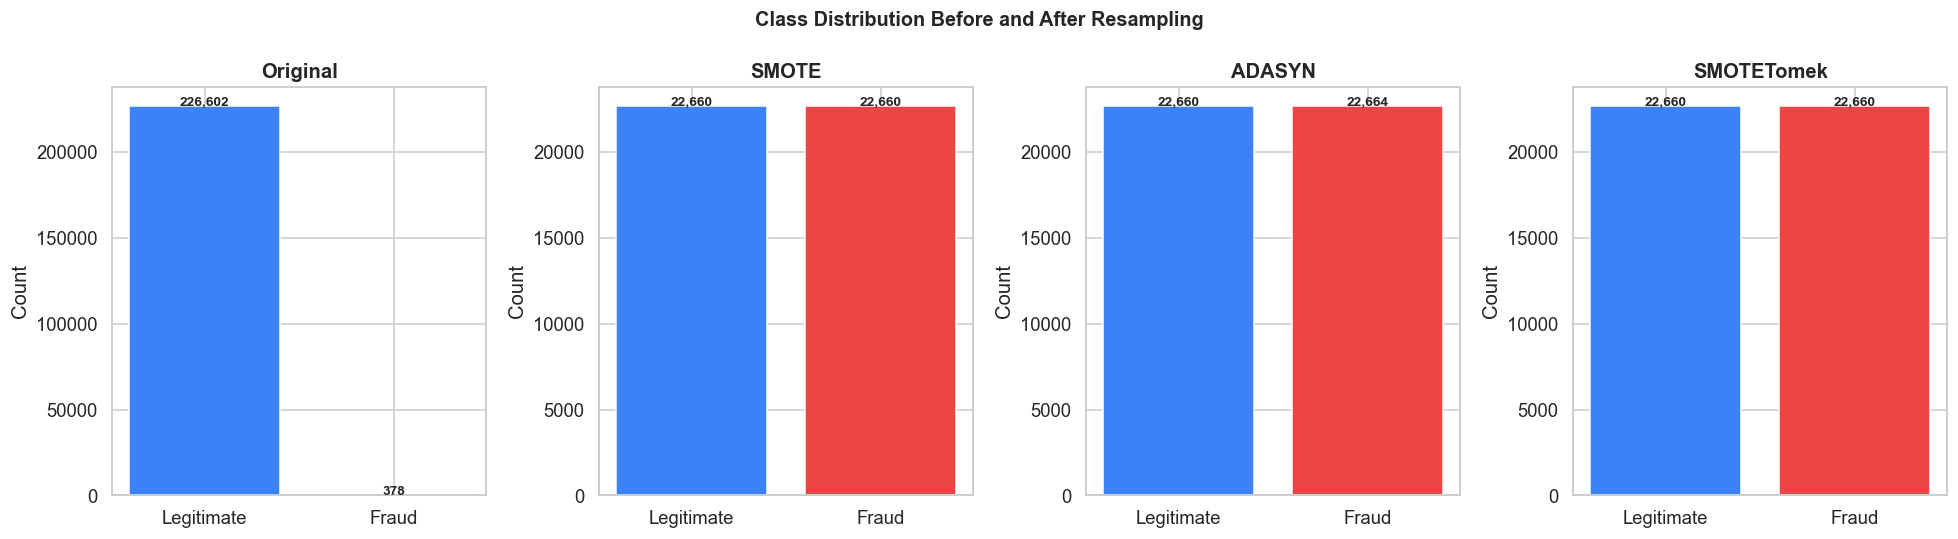

In [10]:
# Visualise resampling results
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

datasets = [('Original', len(y_train) - y_train.sum(), y_train.sum())] + [
    (name, results[name]['legit'], results[name]['fraud'])
    for name in strategies.keys()
]

for ax, (name, legit_n, fraud_n) in zip(axes, datasets):
    bars = ax.bar(['Legitimate', 'Fraud'], [legit_n, fraud_n],
                  color=[LEGIT_COLOR, FRAUD_COLOR], edgecolor='white')
    for bar, val in zip(bars, [legit_n, fraud_n]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                f'{val:,}', ha='center', fontsize=9, fontweight='bold')
    ax.set_title(name, fontweight='bold')
    ax.set_ylabel('Count')

plt.suptitle('Class Distribution Before and After Resampling',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

---
## 7. Build sklearn Pipeline

In [11]:
from imblearn.pipeline import Pipeline as ImbPipeline

# Full pipeline: preprocess -> resample -> (classifier will be added in notebook 03)
# We test with SMOTE here; other strategies will be compared in modeling notebook

full_preprocessor = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  RobustScaler()),
    ]), numeric_cols),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot',  OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
    ]), categorical_cols),
])

print('Preprocessor pipeline built')
print(f'Numeric features:     {len(numeric_cols)}')
print(f'Categorical features: {len(categorical_cols)}')
full_preprocessor

Preprocessor pipeline built
Numeric features:     30
Categorical features: 1


,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


In [12]:
# Get all encoded feature names
full_preprocessor.fit(X_train)

ohe_features = full_preprocessor.named_transformers_['cat']['onehot']\
                                .get_feature_names_out(categorical_cols).tolist()
all_feature_names = numeric_cols + ohe_features

print(f'Total features after encoding: {len(all_feature_names)}')
print(f'Numeric: {len(numeric_cols)} | Encoded categorical: {len(ohe_features)}')

Total features after encoding: 35
Numeric: 30 | Encoded categorical: 5


---
## 8. Save Processed Data

In [13]:
import json

os.makedirs('../data/processed', exist_ok=True)
os.makedirs('../models', exist_ok=True)

# Save train/test splits
train_df = X_train.copy(); train_df[TARGET] = y_train.values
test_df  = X_test.copy();  test_df[TARGET]  = y_test.values

train_df.to_csv('../data/processed/train.csv', index=False)
test_df.to_csv('../data/processed/test.csv',   index=False)

# Save preprocessor
joblib.dump(full_preprocessor, '../models/preprocessor.pkl')

# Save feature names
with open('../models/feature_names.json', 'w') as f:
    json.dump({
        'numeric':     numeric_cols,
        'categorical': categorical_cols,
        'all_encoded': all_feature_names
    }, f, indent=2)

print('Saved:')
print('  data/processed/train.csv')
print('  data/processed/test.csv')
print('  models/preprocessor.pkl')
print('  models/feature_names.json')

Saved:
  data/processed/train.csv
  data/processed/test.csv
  models/preprocessor.pkl
  models/feature_names.json


---
## Summary

In [14]:
print("""
=================================================================
                 FEATURE ENGINEERING SUMMARY
=================================================================

  NEW FEATURES (5)
  - hour               : hour of day from Time (0-23)
  - day                : day number from Time
  - log_amount         : log(Amount + 1) to handle skewness
  - amount_bin         : categorical bins by transaction size
  - high_amount_night  : flag for large transactions at night

  DROPPED
  - Time   (replaced by hour, day)
  - Amount (replaced by log_amount, amount_bin)

  SCALING
  - RobustScaler on numeric features (handles outliers)
  - OneHotEncoder on categorical features

  RESAMPLING STRATEGIES COMPARED
  - SMOTE      : pure oversampling of minority class
  - ADASYN     : adaptive oversampling (harder cases)
  - SMOTETomek : oversampling + boundary cleaning

  NEXT STEP -> 03_modeling.ipynb
  - Train 4 supervised models + Isolation Forest
  - Compare all 3 resampling strategies
  - Optimize decision threshold for business cost
  - Evaluate with PR-AUC (not accuracy or ROC-AUC)
=================================================================
""")


                 FEATURE ENGINEERING SUMMARY

  NEW FEATURES (5)
  - hour               : hour of day from Time (0-23)
  - day                : day number from Time
  - log_amount         : log(Amount + 1) to handle skewness
  - amount_bin         : categorical bins by transaction size
  - high_amount_night  : flag for large transactions at night

  DROPPED
  - Time   (replaced by hour, day)
  - Amount (replaced by log_amount, amount_bin)

  SCALING
  - RobustScaler on numeric features (handles outliers)
  - OneHotEncoder on categorical features

  RESAMPLING STRATEGIES COMPARED
  - SMOTE      : pure oversampling of minority class
  - ADASYN     : adaptive oversampling (harder cases)
  - SMOTETomek : oversampling + boundary cleaning

  NEXT STEP -> 03_modeling.ipynb
  - Train 4 supervised models + Isolation Forest
  - Compare all 3 resampling strategies
  - Optimize decision threshold for business cost
  - Evaluate with PR-AUC (not accuracy or ROC-AUC)

